In [17]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
tokenizer

BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}

In [18]:
# !wget https://archive.ics.uci.edu/static/public/20/census+income.zip
# !unzip census+income.zip

In [19]:
import pandas as pd

df = pd.read_csv('adult.data', names = ['age','workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'])
print(len(df))
df

32561


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [20]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [ ]:
import numpy as np
import torch

DROP_P = 0.2

def concatenate_text(x_full):

    x = {}
    for i, j in x_full.items():
        x[i] = j if np.random.random() > DROP_P else '[UNK]'
        # print(i)
    # print(x)
    
    text = "".join([f"I have information about a person. ",
            f"He is {x['age'] if np.random.random() > DROP_P else '[UNK]'} years old. ",
            f"His sex is {x['sex']}. ",
            f"His workclass is {x['workclass']}. ",
            f"There are approximately {x['fnlwgt']} people in the US like him. ",
            f"His education is {x['education']}. ",
            f"His education duration is {x['education-num']} years. ",
            f"His marital status is {x['marital-status']}. ",
            f"His occupation is {x['occupation']}. ",
            f"His relationship is {x['relationship']}. ",
            f"His race is {x['race']}. ",
            f"His capital gain is {x['capital-gain']}. ",
            f"His capital loss is {x['capital-loss']}. ",
            f"He works {x['hours-per-week']} hours per week. ",
            f"His native country is {x['native-country']}."])

    
    return text

concatenate_text(df.iloc[0])

'I have information about a person. He is [UNK] years old. His sex is  Male. His workclass is  State-gov. There are approximately 77516 people in the US like him. His education is  Bachelors. His education duration is [UNK] years. His marital status is [UNK]. His occupation is [UNK]. His relationship is  Not-in-family. His race is  White. His capital gain is [UNK]. His capital loss is 0. He works 40 hours per week. His nativecountry is  United-States.'

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('income', axis =1),
                                                    df['income'],
                                                    test_size=.2,
                                                    random_state = 42)
y_train = y_train.replace({' >50K':1, ' <=50K':0})
y_test = y_test.replace({' >50K':1, ' <=50K':0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

/var/folders/p4/w2f9dq2d091g_4svlqrt38h80000gn/T/ipykernel_61838/2779352629.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({' >50K':1, ' <=50K':0})
/var/folders/p4/w2f9dq2d091g_4svlqrt38h80000gn/T/ipykernel_61838/2779352629.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_test.replace({' >50K':1, ' <=50K':0})


In [23]:
X_train['text'].iloc[0]

'I have information about a person. He is 33 years old. His sex is  Female. His workclass is  Local-gov. There are approximately 198183 people in the US like him. His education is  Bachelors. His education duration is 13 years. His marital status is [UNK]. His occupation is  Prof-specialty. His relationship is  Not-in-family. His race is  White. His capital gain is [UNK]. His capital loss is 0. He works 50 hours per week. His nativecountry is [UNK].'

In [24]:
len(X_train)

26048

In [25]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np
import evaluate

# Define label mappings
# id2label = {0: "NOT-DONATE", 1: "DONATE"}
# label2id = {"NOT-DONATE": 0, "DONATE": 1}

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

Map:   0%|          | 0/26048 [00:00<?, ? examples/s]

Map:   0%|          | 0/6513 [00:00<?, ? examples/s]

Map:   0%|          | 0/26048 [00:00<?, ? examples/s]

Map:   0%|          | 0/6513 [00:00<?, ? examples/s]

In [26]:
tokenized_train_dataset[0].keys()

dict_keys(['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])

In [27]:
tokenized_train_dataset[0]['text']

'I have information about a person. He is 33 years old. His sex is  Female. His workclass is  Local-gov. There are approximately 198183 people in the US like him. His education is  Bachelors. His education duration is 13 years. His marital status is [UNK]. His occupation is  Prof-specialty. His relationship is  Not-in-family. His race is  White. His capital gain is [UNK]. His capital loss is 0. He works 50 hours per week. His nativecountry is [UNK].'

In [28]:
tokenized_train_dataset[0]['label']

1

In [29]:
import torch
if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")
    

tensor([1.], device='mps:0')


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/4070 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 8.3708, 'grad_norm': 16.127370834350586, 'learning_rate': 0.09975429975429977, 'epoch': 0.02}
{'loss': 7.9061, 'grad_norm': 9.938533782958984, 'learning_rate': 0.09950859950859951, 'epoch': 0.05}
{'loss': 3.9262, 'grad_norm': 21.398439407348633, 'learning_rate': 0.09926289926289927, 'epoch': 0.07}
{'loss': 2.0616, 'grad_norm': 1.9170405864715576, 'learning_rate': 0.09901719901719902, 'epoch': 0.1}
{'loss': 2.0656, 'grad_norm': 7.0972981452941895, 'learning_rate': 0.09877149877149877, 'epoch': 0.12}
{'loss': 6.3767, 'grad_norm': 6.599380016326904, 'learning_rate': 0.09852579852579853, 'epoch': 0.15}
{'loss': 3.0, 'grad_norm': 2.8925938606262207, 'learning_rate': 0.09828009828009829, 'epoch': 0.17}
{'loss': 7.4181, 'grad_norm': 20.73406219482422, 'learning_rate': 0.09803439803439803, 'epoch': 0.2}
{'loss': 2.2542, 'grad_norm': 19.67717742919922, 'learning_rate': 0.0977886977886978, 'epoch': 0.22}
{'loss': 5.6581, 'grad_norm': 5.315472602844238, 'learning_rate': 0.097542997542997

  0%|          | 0/102 [00:00<?, ?it/s]

...

  0%|          | 0/102 [00:00<?, ?it/s]

test f1 0.31384307846076964
test precision 0.7302325581395349
test recall 0.19987269255251433
test accuracy 0.7891908490710886
test roc_auc 0.8178752587945051



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/407 [00:00<?, ?it/s]

train f1 0.4988190836088805
train precision 0.6118192352259559
train recall 0.42105263157894735
train accuracy 0.7963375307125307
train roc_auc 0.818369640650777


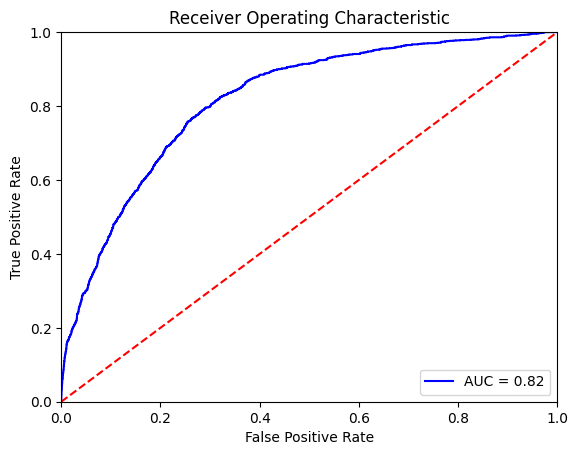

In [30]:
from transformers import BertForSequenceClassification
from transformers import DataCollatorWithPadding
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

def find_best_threshold(y_true, y_pred):
    best_threshold = 0.0
    best_f1 = 0.0
    best_accuracy = 0.0
    
    thresholds = np.arange(0.0, 1.01, 0.01)
    for threshold in thresholds:
        y_pred_binary = (y_pred >= threshold).astype(int)
        
        current_f1 = f1_score(y_true, y_pred_binary)
        
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = threshold
            best_accuracy = accuracy_score(y_true, y_pred_binary)
    
    return best_f1, best_threshold

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/4070 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.5415, 'grad_norm': 47.55000686645508, 'learning_rate': 2.0000000000000002e-07, 'epoch': 0.02}
{'loss': 0.5467, 'grad_norm': 43.88236618041992, 'learning_rate': 4.0000000000000003e-07, 'epoch': 0.05}
{'loss': 0.5324, 'grad_norm': 22.813011169433594, 'learning_rate': 6.000000000000001e-07, 'epoch': 0.07}
{'loss': 0.4752, 'grad_norm': 7.814632415771484, 'learning_rate': 8.000000000000001e-07, 'epoch': 0.1}
{'loss': 0.4866, 'grad_norm': 29.682167053222656, 'learning_rate': 1.0000000000000002e-06, 'epoch': 0.12}
{'loss': 0.5055, 'grad_norm': 7.32445764541626, 'learning_rate': 1.2000000000000002e-06, 'epoch': 0.15}
{'loss': 0.498, 'grad_norm': 9.375103950500488, 'learning_rate': 1.4000000000000001e-06, 'epoch': 0.17}
{'loss': 0.4902, 'grad_norm': 13.106553077697754, 'learning_rate': 1.6000000000000001e-06, 'epoch': 0.2}
{'loss': 0.5219, 'grad_norm': 16.91002082824707, 'learning_rate': 1.8000000000000001e-06, 'epoch': 0.22}
{'loss': 0.4836, 'grad_norm': 18.818159103393555, 'learnin

  0%|          | 0/102 [00:00<?, ?it/s]

{'eval_loss': 0.3576359152793884, 'eval_roc_auc': 0.8852843203953898, 'eval_runtime': 50.1823, 'eval_samples_per_second': 129.787, 'eval_steps_per_second': 2.033, 'epoch': 1.0}


...

  0%|          | 0/102 [00:00<?, ?it/s]

test f1 0.6678926075763149
test precision 0.7909407665505227
test recall 0.5779758115849777
test accuracy 0.8613542146476278
test roc_auc 0.9152950804764935



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/407 [00:00<?, ?it/s]

train f1 0.7361122180600941
train precision 0.7357017683606819
train recall 0.7365231259968102
train accuracy 0.8728885135135135
train roc_auc 0.9333970509658809


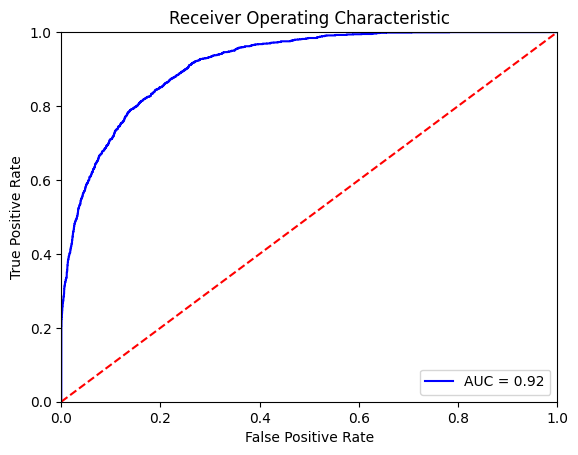

In [31]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [32]:
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score

scores = []
n_iter = 1000
multi = False
y_pred = (pred[0][:, 1] >= thr).astype(int)
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.9153±0.0037',
 'F1': '0.6681±0.0103',
 'Accuracy': '0.8615±0.0042',
 'Precision': '0.7906±0.0120',
 'Recall': '0.5785±0.0122'}

/var/folders/p4/w2f9dq2d091g_4svlqrt38h80000gn/T/ipykernel_61838/1821975196.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({' >50K':1, ' <=50K':0})
/var/folders/p4/w2f9dq2d091g_4svlqrt38h80000gn/T/ipykernel_61838/1821975196.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_test.replace({' >50K':1, ' <=50K':0})


Map:   0%|          | 0/26048 [00:00<?, ? examples/s]

Map:   0%|          | 0/6513 [00:00<?, ? examples/s]

Map:   0%|          | 0/26048 [00:00<?, ? examples/s]

Map:   0%|          | 0/6513 [00:00<?, ? examples/s]

...

  0%|          | 0/102 [00:00<?, ?it/s]

test f1 0.006345177664974619
test precision 1.0
test recall 0.003182686187141948
test accuracy 0.7595578074619991
test roc_auc 0.7730367360039733



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/407 [00:00<?, ?it/s]

train f1 0.24310389275586491
train precision 0.633736559139785
train recall 0.15039872408293462
train accuracy 0.7745700245700246
train roc_auc 0.7693070514932658


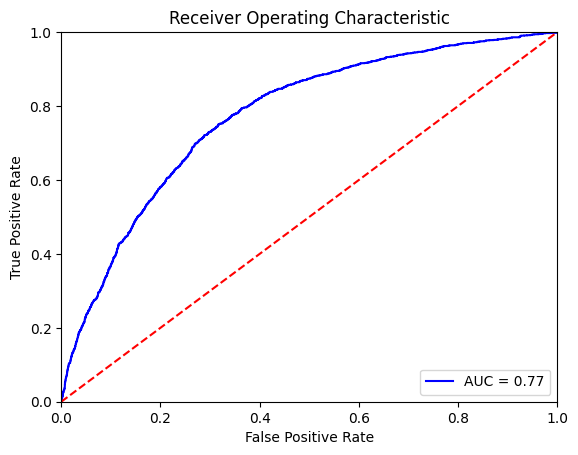

In [33]:
DROP_P = 0.5

X_train, X_test, y_train, y_test = train_test_split(df.drop('income', axis =1),
                                                    df['income'],
                                                    test_size=.2,
                                                    random_state = 42)
y_train = y_train.replace({' >50K':1, ' <=50K':0})
y_test = y_test.replace({' >50K':1, ' <=50K':0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/4070 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.5346, 'grad_norm': 27.275650024414062, 'learning_rate': 2.0000000000000002e-07, 'epoch': 0.02}
{'loss': 0.5524, 'grad_norm': 33.27357864379883, 'learning_rate': 4.0000000000000003e-07, 'epoch': 0.05}
{'loss': 0.5662, 'grad_norm': 11.52362060546875, 'learning_rate': 6.000000000000001e-07, 'epoch': 0.07}
{'loss': 0.4841, 'grad_norm': 7.189134120941162, 'learning_rate': 8.000000000000001e-07, 'epoch': 0.1}
{'loss': 0.5007, 'grad_norm': 20.618804931640625, 'learning_rate': 1.0000000000000002e-06, 'epoch': 0.12}
{'loss': 0.5266, 'grad_norm': 8.498098373413086, 'learning_rate': 1.2000000000000002e-06, 'epoch': 0.15}
{'loss': 0.5249, 'grad_norm': 16.86362648010254, 'learning_rate': 1.4000000000000001e-06, 'epoch': 0.17}
{'loss': 0.5273, 'grad_norm': 12.451955795288086, 'learning_rate': 1.6000000000000001e-06, 'epoch': 0.2}
{'loss': 0.5484, 'grad_norm': 6.05657434463501, 'learning_rate': 1.8000000000000001e-06, 'epoch': 0.22}
{'loss': 0.5129, 'grad_norm': 4.9838948249816895, 'learni

  0%|          | 0/102 [00:00<?, ?it/s]

{'eval_loss': 0.4284387230873108, 'eval_roc_auc': 0.8445373074964302, 'eval_runtime': 51.2337, 'eval_samples_per_second': 127.123, 'eval_steps_per_second': 1.991, 'epoch': 1.0}


...

  0%|          | 0/102 [00:00<?, ?it/s]

test f1 0.4370860927152318
test precision 0.850828729281768
test recall 0.29408020369191595
test accuracy 0.8172884999232305
test roc_auc 0.8745278457349043



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/407 [00:00<?, ?it/s]

train f1 0.6610412623407308
train precision 0.7018455473929404
train recall 0.6247208931419458
train accuracy 0.8457847051597052
train roc_auc 0.8980626985052422


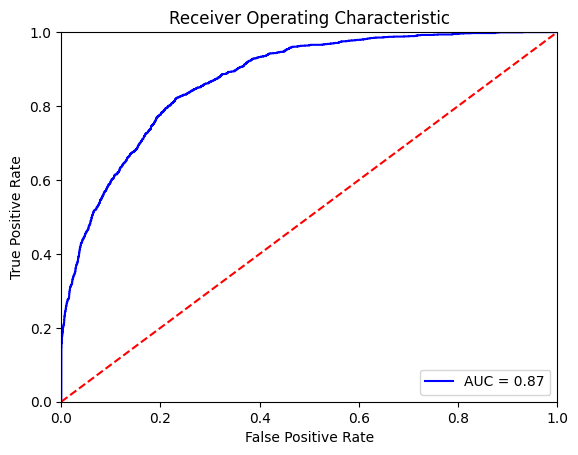

In [34]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [35]:
scores = []
n_iter = 1000
multi = False
y_pred = (pred[0][:, 1] >= thr).astype(int)
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.8743±0.0048',
 'F1': '0.4376±0.0131',
 'Accuracy': '0.8175±0.0050',
 'Precision': '0.8507±0.0154',
 'Recall': '0.2946±0.0111'}

/var/folders/p4/w2f9dq2d091g_4svlqrt38h80000gn/T/ipykernel_61838/3481176268.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({' >50K':1, ' <=50K':0})
/var/folders/p4/w2f9dq2d091g_4svlqrt38h80000gn/T/ipykernel_61838/3481176268.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_test.replace({' >50K':1, ' <=50K':0})


Map:   0%|          | 0/26048 [00:00<?, ? examples/s]

Map:   0%|          | 0/6513 [00:00<?, ? examples/s]

Map:   0%|          | 0/26048 [00:00<?, ? examples/s]

Map:   0%|          | 0/6513 [00:00<?, ? examples/s]

...

test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.7587901120835252
test roc_auc 0.5930430163673276



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/407 [00:00<?, ?it/s]

train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.7592905405405406
train roc_auc 0.599709442273349


/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


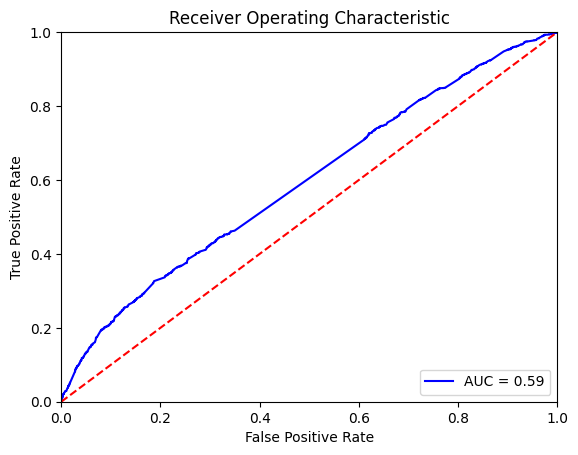

In [36]:
DROP_P = 0.9

X_train, X_test, y_train, y_test = train_test_split(df.drop('income', axis =1),
                                                    df['income'],
                                                    test_size=.2,
                                                    random_state = 42)
y_train = y_train.replace({' >50K':1, ' <=50K':0})
y_test = y_test.replace({' >50K':1, ' <=50K':0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/4070 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.5412, 'grad_norm': 10.292356491088867, 'learning_rate': 2.0000000000000002e-07, 'epoch': 0.02}
{'loss': 0.5678, 'grad_norm': 10.878592491149902, 'learning_rate': 4.0000000000000003e-07, 'epoch': 0.05}
{'loss': 0.5862, 'grad_norm': 6.013176441192627, 'learning_rate': 6.000000000000001e-07, 'epoch': 0.07}
{'loss': 0.5173, 'grad_norm': 1.9323747158050537, 'learning_rate': 8.000000000000001e-07, 'epoch': 0.1}
{'loss': 0.5135, 'grad_norm': 5.638256549835205, 'learning_rate': 1.0000000000000002e-06, 'epoch': 0.12}
{'loss': 0.5462, 'grad_norm': 2.4513027667999268, 'learning_rate': 1.2000000000000002e-06, 'epoch': 0.15}
{'loss': 0.5624, 'grad_norm': 6.700497150421143, 'learning_rate': 1.4000000000000001e-06, 'epoch': 0.17}
{'loss': 0.549, 'grad_norm': 1.8987964391708374, 'learning_rate': 1.6000000000000001e-06, 'epoch': 0.2}
{'loss': 0.5712, 'grad_norm': 2.542151927947998, 'learning_rate': 1.8000000000000001e-06, 'epoch': 0.22}
{'loss': 0.5541, 'grad_norm': 3.1992745399475098, 'lear

  0%|          | 0/102 [00:00<?, ?it/s]

{'eval_loss': 0.5253559947013855, 'eval_roc_auc': 0.6614970449061436, 'eval_runtime': 51.0681, 'eval_samples_per_second': 127.536, 'eval_steps_per_second': 1.997, 'epoch': 1.0}


...

  0%|          | 0/102 [00:00<?, ?it/s]

test f1 0.08343409915356712
test precision 0.8313253012048193
test recall 0.04392106938255888
test accuracy 0.7672347612467373
test roc_auc 0.6915317620746941



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/407 [00:00<?, ?it/s]

train f1 0.2902829028290283
train precision 0.6344086021505376
train recall 0.18819776714513556
train accuracy 0.7784858722358723
train roc_auc 0.714303437212065


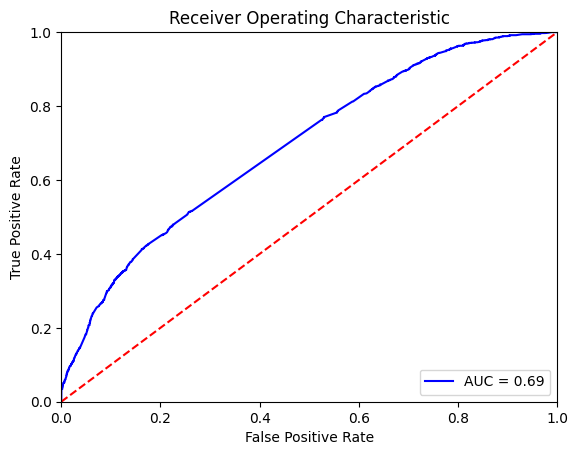

In [37]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [38]:
scores = []
n_iter = 1000
multi = False
y_pred = (pred[0][:, 1] >= thr).astype(int)
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.6915±0.0075',
 'F1': '0.0836±0.0098',
 'Accuracy': '0.7674±0.0056',
 'Precision': '0.8297±0.0419',
 'Recall': '0.0441±0.0054'}

/var/folders/p4/w2f9dq2d091g_4svlqrt38h80000gn/T/ipykernel_61838/4007338418.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train = y_train.replace({' >50K':1, ' <=50K':0})
/var/folders/p4/w2f9dq2d091g_4svlqrt38h80000gn/T/ipykernel_61838/4007338418.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_test.replace({' >50K':1, ' <=50K':0})


Map:   0%|          | 0/26048 [00:00<?, ? examples/s]

Map:   0%|          | 0/6513 [00:00<?, ? examples/s]

Map:   0%|          | 0/26048 [00:00<?, ? examples/s]

Map:   0%|          | 0/6513 [00:00<?, ? examples/s]

...

  0%|          | 0/102 [00:00<?, ?it/s]

test f1 0.2167321729365525
test precision 0.919047619047619
test recall 0.12285168682367918
test accuracy 0.7858129894058038
test roc_auc 0.852845007175534



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/407 [00:00<?, ?it/s]

train f1 0.5787310098302055
train precision 0.658130081300813
train recall 0.5164274322169059
train accuracy 0.8190264127764127
train roc_auc 0.8507129617220042


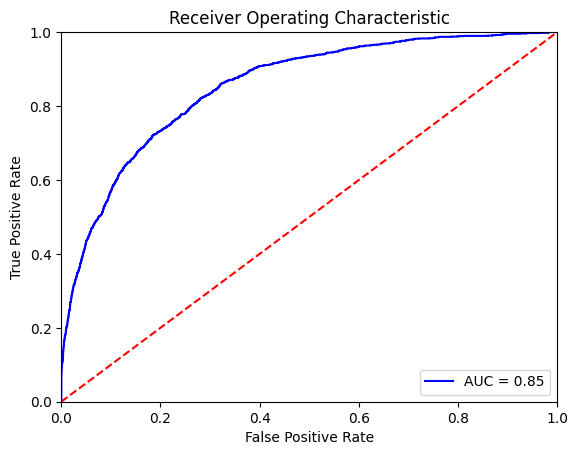

In [39]:
DROP_P = 0

X_train, X_test, y_train, y_test = train_test_split(df.drop('income', axis =1),
                                                    df['income'],
                                                    test_size=.2,
                                                    random_state = 42)
y_train = y_train.replace({' >50K':1, ' <=50K':0})
y_test = y_test.replace({' >50K':1, ' <=50K':0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/4070 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.4982, 'grad_norm': 38.24666976928711, 'learning_rate': 2.0000000000000002e-07, 'epoch': 0.02}
{'loss': 0.5161, 'grad_norm': 43.37982177734375, 'learning_rate': 4.0000000000000003e-07, 'epoch': 0.05}
{'loss': 0.4678, 'grad_norm': 18.522212982177734, 'learning_rate': 6.000000000000001e-07, 'epoch': 0.07}
{'loss': 0.4527, 'grad_norm': 10.376178741455078, 'learning_rate': 8.000000000000001e-07, 'epoch': 0.1}
{'loss': 0.4524, 'grad_norm': 31.844579696655273, 'learning_rate': 1.0000000000000002e-06, 'epoch': 0.12}
{'loss': 0.4594, 'grad_norm': 7.730495452880859, 'learning_rate': 1.2000000000000002e-06, 'epoch': 0.15}
{'loss': 0.4607, 'grad_norm': 8.827260971069336, 'learning_rate': 1.4000000000000001e-06, 'epoch': 0.17}
{'loss': 0.4292, 'grad_norm': 7.082602024078369, 'learning_rate': 1.6000000000000001e-06, 'epoch': 0.2}
{'loss': 0.4794, 'grad_norm': 18.94792938232422, 'learning_rate': 1.8000000000000001e-06, 'epoch': 0.22}
{'loss': 0.467, 'grad_norm': 29.25786018371582, 'learnin

  0%|          | 0/102 [00:00<?, ?it/s]

{'eval_loss': 0.35747089982032776, 'eval_roc_auc': 0.9012749034568016, 'eval_runtime': 49.6097, 'eval_samples_per_second': 131.285, 'eval_steps_per_second': 2.056, 'epoch': 1.0}


...

  0%|          | 0/102 [00:00<?, ?it/s]

test f1 0.6658896658896659
test precision 0.8544366899302094
test recall 0.5455124124761298
test accuracy 0.8679563949025026
test roc_auc 0.9284643944871908



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/407 [00:00<?, ?it/s]

train f1 0.7646786155747837
train precision 0.7415343122565178
train recall 0.7893141945773525
train accuracy 0.8830620393120393
train roc_auc 0.9463322666284757


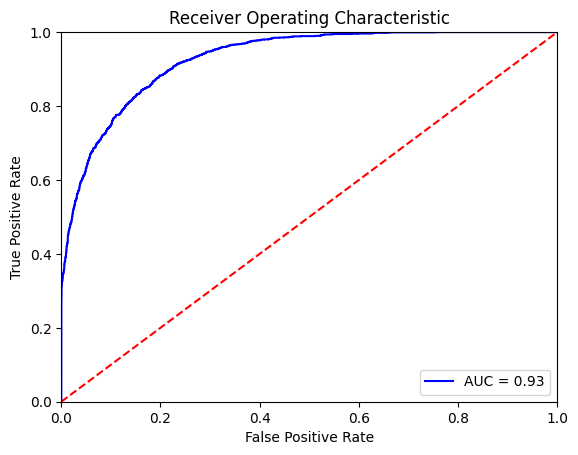

In [40]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [41]:
scores = []
n_iter = 1000
multi = False
y_pred = (pred[0][:, 1] >= thr).astype(int)
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.9285±0.0033',
 'F1': '0.6663±0.0105',
 'Accuracy': '0.8682±0.0042',
 'Precision': '0.8545±0.0115',
 'Recall': '0.5461±0.0120'}